# Using Colab

Colab, or Colaboratory is an interactive notebook provided by Google (primarily) for writing and running Python through a browser. 

Although Colab is primarily used for coding in Python, apparently we can also use it for R (#Rstats).

When you launch a Google Colab notebook, much of the software we will need is already installed.
Because the notebooks in Colab have specific software preinstalled, and no more, you will often need to install software before you can run the rest of the code in a notebook. To enable this, when necessary, in the first code cell of each notebook in this class, we will have the following code (or a variant thereof depending on what is needed or if the default installations of Colab change).
Running this code will not affect running your notebook on your local machine; the same notebook will work on your local machine or on Colab. 

When using Stan, you will need to install Stan in your Colab session using `cmdstanpy.install_cmdstan()`, which can take some time, usually several minutes.

In [1]:
import os, sys, subprocess
if "google.colab" in sys.modules:
    cmd = "pip install --upgrade iqplot colorcet datashader bebi103 arviz cmdstanpy watermark"
    process = subprocess.Popen(cmd.split(), stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    stdout, stderr = process.communicate()
    import cmdstanpy; cmdstanpy.install_cmdstan()
else:
    data_path = "drive/MyDrive/colab_notebooks/mydata/"

Installing CmdStan version: 2.29.1
Install directory: /root/.cmdstan
Download successful, file: /tmp/tmpjus20k4k
Extracting distribution
Unpacked download as cmdstan-2.29.1
Building version cmdstan-2.29.1, may take several minutes, depending on your system.
Test model compilation
Installed cmdstan-2.29.1


In [2]:
# number of processors
!cat /proc/cpuinfo | grep processor | wc -l
# processor spec
!cat /proc/cpuinfo | head -10

2
processor	: 0
vendor_id	: AuthenticAMD
cpu family	: 23
model		: 49
model name	: AMD EPYC 7B12
stepping	: 0
microcode	: 0x1000065
cpu MHz		: 2249.996
cache size	: 512 KB
physical id	: 0


In [3]:
# show disk space in GB
!pwd
!df -BG `pwd`

/content
Filesystem     1G-blocks  Used Available Use% Mounted on
overlay             108G   41G       67G  38% /


# Using R on Colab

To run R in Colab, you need to use the rpy2 package in the Python runtime. This method allows you to execute R and Python syntax together. To to so, run `rmagic` by executing this command `%load_ext rpy2.ipython`.


In [4]:
# enable R
%load_ext rpy2.ipython 

In [5]:
# which R?
!R --version

R version 4.1.3 (2022-03-10) -- "One Push-Up"
Copyright (C) 2022 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu (64-bit)

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under the terms of the
GNU General Public License versions 2 or 3.
For more information about these matters see
https://www.gnu.org/licenses/.



After that, every time you want to use R, add `%%R` in the beginning of each cell.

In [ ]:
%%R
# inspect R packages
.libPaths()
library()

In [7]:
%%R
library("tidyverse")
library("magrittr")
library("tibble")

R[write to console]: ── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

R[write to console]: ✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.8
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1

R[write to console]: ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

R[write to console]: 
Attaching package: ‘magrittr’


R[write to console]: The following object is masked from ‘package:purrr’:

    set_names


R[write to console]: The following object is masked from ‘package:tidyr’:

    extract




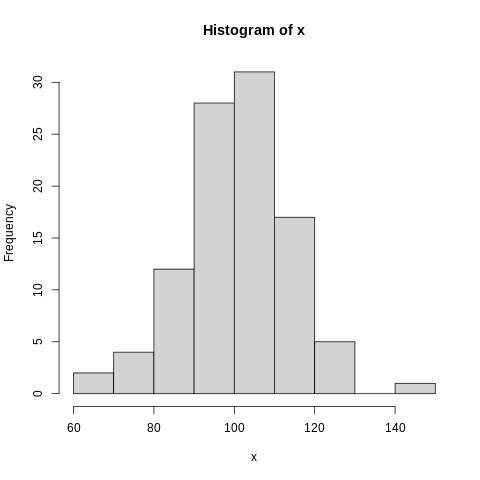

In [8]:
%%R
x <- rnorm(100, 100, 15)
hist(x)

R[write to console]: `stat_bin()` using `bins = 30`. Pick better value with `binwidth`.



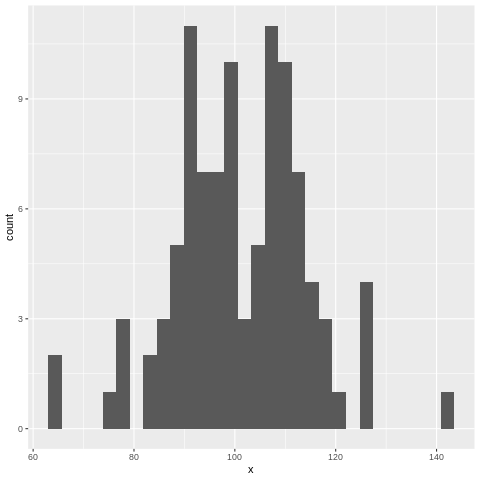

In [9]:
%%R
tibble(x = x) %>%
  ggplot(aes(x)) +
  geom_histogram()

In [ ]:
%%R
install.packages("rio")

In [ ]:
%%R
install.packages("here")

## Colab import file from Google Drive
### Mount the Google Drive to Google Colab

To import in Colab your files stored on Google Drive, you need to connect Colab to Google Drive. To this purpose, execute the following instructions. This requires providing your password for your Google Drive account.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We can understand where is the working directory in this manner:

In [13]:
%%R
here::here()

[1] "/content"


If you explore the organization of the folders by clicking on the folder icon on the menu bar on the left. By doing so, you'll see that in the /content folder there is a folder called drive, which has inside MyDrive -- I assume that that is your Google Drive folder. What is inside that folder depends on what you have put there. I have created, among the others, a folder called colab_notebooks (please, do not use spaces in the names of folders or files!!!). Inside colab_notebooks I have a folder called mydata. In the mydata folder I put the data that I want to read in R.

Given the folder structure that I have described above, the address of the file kidiq.dta (that I have put in mydata) is what I have specified below. Please note that the folder and the kidiq.dta data file are NOT present on you Google Drive by default. I have created them. To do a test, you have to manually create a folder in which you put all your colab projects and, I suggest, inside that folder another folder in which you put the data files. Then, using the names of YOUR folders and files, you can read them in the working memory of R by using a sintax SIMILAR to the one indicated below.

In [14]:
%%R
d <- rio::import("/content/drive/MyDrive/colab_notebooks/mydata/kidiq.dta")

Also the getwd() instruction works:

In [ ]:
%%R
getwd()

[1] "/content"


We can also specify the address of the file using the here() function (this requires that first you install the package here and then load the here library):

In [15]:
%%R
d1 <- rio::import(here::here("drive", "MyDrive", "colab_notebooks", "mydata", "kidiq.dta"))

To test the functions of tidyverse I use the function glimpse()

In [ ]:
%%R
glimpse(d1)

Rows: 434
Columns: 5
$ kid_score <dbl> 65, 98, 85, 83, 115, 98, 69, 106, 102, 95, 91, 58, 84, 78, 1…
$ mom_hs    <dbl> 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, …
$ mom_iq    <dbl> 121.11753, 89.36188, 115.44316, 99.44964, 92.74571, 107.9018…
$ mom_work  <dbl> 4, 4, 4, 3, 4, 1, 4, 3, 1, 1, 1, 4, 4, 4, 2, 1, 3, 3, 4, 3, …
$ mom_age   <dbl> 27, 25, 27, 25, 27, 18, 20, 23, 24, 19, 23, 24, 27, 26, 24, …


Below I run a linear regression, to see if it works, with the function lm(). I examine the results with summary(). I use the DataFrame d1, which contains the data of the file kidiq.dta. Everything works fine.

In [ ]:
%%R
fm <- lm(kid_score ~ mom_iq, data = d1)
summary(fm)


Call:
lm(formula = kid_score ~ mom_iq, data = d1)

Residuals:
    Min      1Q  Median      3Q     Max 
-56.753 -12.074   2.217  11.710  47.691 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 25.79978    5.91741    4.36 1.63e-05 ***
mom_iq       0.60997    0.05852   10.42  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 18.27 on 432 degrees of freedom
Multiple R-squared:  0.201,	Adjusted R-squared:  0.1991 
F-statistic: 108.6 on 1 and 432 DF,  p-value: < 2.2e-16



I test the functions of the package prob. Remember that you first need to install the packages, then to load them.

In [ ]:
%%R
install.packages("prob")

In [ ]:
%%R
library(prob)

It works fine.

In [18]:
%%R
tosscoin(3)

  toss1 toss2 toss3
1     H     H     H
2     T     H     H
3     H     T     H
4     T     T     H
5     H     H     T
6     T     H     T
7     H     T     T
8     T     T     T


# Installing and running cmdstan on Colab


Now the more complicated part: cmdstan. We already installed it by running the first cell of this notebook. Now we test if it works. The cell below load some packages. Remember that we are in a Python environment, NOT in an R environment.

In [19]:
import numpy as np

import cmdstanpy
import arviz as az

import bokeh.plotting
import bokeh.io
bokeh.io.output_notebook()

We define a list which contains the data in a format appropriate for Stan:

In [20]:
schools_data = {
    "J": 8,
    "y": [28, 8, -3, 7, -1, 1, 18, 12],
    "sigma": [15, 10, 16, 11, 9, 11, 10, 18],
}

Now we create the model for this particular example. This is a famous (simple) model that is often used to test if the installation of Stan works on a particular machine -- or, in this case, on Colab. Note that the syntax is slightly different with respect to what we do in R: here we use a triple quote, """, at be beginning and at the end of the specification of the model. 

In [21]:
schools_code = """
data {
  int<lower=0> J; // number of schools
  vector[J] y; // estimated treatment effects
  vector<lower=0>[J] sigma; // s.e. of effect estimates
}

parameters {
  real mu;
  real<lower=0> tau;
  vector[J] eta;
}

transformed parameters {
  vector[J] theta = mu + tau * eta;
}

model {
  eta ~ normal(0, 1);
  y ~ normal(theta, sigma);
}
"""

With the instruction below, we write the model that we have specified above in a file.

In [22]:
with open("schools_code.stan", "w") as f:
    f.write(schools_code)

Now we compile the code in a C++ executable called sm:

In [23]:
sm = cmdstanpy.CmdStanModel(stan_file="schools_code.stan")

INFO:cmdstanpy:compiling stan file /content/schools_code.stan to exe file /content/schools_code
INFO:cmdstanpy:compiled model executable: /content/schools_code


We perform the MCMC sampling and we save the results in an object called samples:

In [24]:
samples = sm.sample(
    data=schools_data, 
    chains=4,
    iter_sampling=3000,
    output_dir="./", 
    show_progress=False
    )

INFO:cmdstanpy:CmdStan start processing
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [2] start processing
INFO:cmdstanpy:Chain [1] done processing
INFO:cmdstanpy:Chain [3] start processing
INFO:cmdstanpy:Chain [2] done processing
INFO:cmdstanpy:Chain [4] start processing
INFO:cmdstanpy:Chain [3] done processing
INFO:cmdstanpy:Chain [4] done processing


We examine the results:

In [26]:
samples.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
name,,,,,,,,,
lp__,-4.900,0.0420,2.60,-9.500,-4.600,-1.0,3800.0,4500.0,1.0
mu,7.900,0.0760,5.10,-0.310,7.900,16.0,4500.0,5300.0,1.0
tau,6.600,0.0820,5.50,0.500,5.400,17.0,4400.0,5200.0,1.0
eta[1],0.390,0.0096,0.95,-1.200,0.410,1.9,9879.0,11608.0,1.0
eta[2],-0.017,0.0084,0.86,-1.400,-0.013,1.4,10486.0,12322.0,1.0
eta[3],-0.210,0.0089,0.94,-1.700,-0.220,1.3,11067.0,13004.0,1.0
eta[4],-0.038,0.0086,0.89,-1.500,-0.046,1.4,10578.0,12430.0,1.0
eta[5],-0.370,0.0092,0.87,-1.800,-0.390,1.1,8895.0,10452.0,1.0
eta[6],-0.210,0.0088,0.90,-1.700,-0.220,1.3,10386.0,12205.0,1.0


Or, more simply

In [29]:
samples.summary().loc[['mu', 'tau']]

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
name,,,,,,,,,
mu,7.9,0.076,5.1,-0.31,7.9,16.0,4500.0,5300.0,1.0
tau,6.6,0.082,5.5,0.50,5.4,17.0,4400.0,5200.0,1.0


We create a figure with the posterior estimates:

In [27]:
post = az.from_cmdstanpy(samples)

In [28]:
# Make a plot of samples
p = bokeh.plotting.figure(
    frame_height=250, frame_width=250, x_axis_label="μ", y_axis_label="τ"
)
p.circle(
    np.ravel(post.posterior["mu"]), 
    np.ravel(post.posterior["tau"]), 
    alpha=0.1
)

bokeh.io.show(p)

In case is needed, we can print the directory in which cmdstan has been installed:

In [ ]:
cmdstanpy.cmdstan_path()

'/root/.cmdstan/cmdstan-2.29.1'

## Computing environment

In [30]:
%load_ext watermark
%watermark -v -p numpy,bokeh,cmdstanpy,arviz,jupyterlab
print("CmdStan : {0:d}.{1:d}".format(*cmdstanpy.cmdstan_version()))

Python implementation: CPython
Python version       : 3.7.13
IPython version      : 5.5.0

numpy     : 1.21.5
bokeh     : 2.3.3
cmdstanpy : 1.0.1
arviz     : 0.12.0
jupyterlab: not installed

CmdStan : 2.29
